# Olist E-Commerce Dataset — End-to-End Exploratory Data Analysis

This notebook connects all 8 raw tables of the Brazilian **Olist** e-commerce
dataset into a single analytical view, then walks through a full EDA:

1. Setup & data loading
2. Data quality checks (per table)
3. Merging everything into one master dataframe
4. Order & revenue trends over time
5. Customers & geography
6. Products & categories
7. Payments
8. Delivery performance
9. Reviews / customer satisfaction
10. Correlation & key takeaways

**Tables used**
| Table | Grain | Role |
|---|---|---|
| `orders` | 1 row / order | backbone |
| `customers` | 1 row / customer | who bought |
| `order_items` | 1 row / item in an order | what & how much |
| `order_payments` | 1+ rows / order | how they paid |
| `products` | 1 row / product | product attributes |
| `product_category_name_translation` | 1 row / category | PT→EN category names |
| `sellers` | 1 row / seller | who sold |
| `reviews` | 1 row / order (review) | satisfaction |
| `geolocation` | many rows / zip prefix | lat/lng for maps |


## 1. Setup

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

DATA_DIR = "data"


In [9]:
customers   = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\Cleaned dataset\customers_cleaned.csv")
geoloc      = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\cleaned dataset\olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\Cleaned dataset\order_items_cleaned.csv")
payments    = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\Cleaned dataset\order_payments_cleaned.csv")
orders      = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\Cleaned dataset\orders_cleaned.csv")
cat_trans   = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\cleaned dataset\product_category_name_translation.csv", encoding="utf-8-sig")
products    = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\cleaned dataset\products_cleaned.csv")
reviews     = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\cleaned dataset\reviews_cleaned.csv")
sellers     = pd.read_csv(r"D:\courses\Data Analytics\NTI\Final Project\cleaned dataset\sellers_cleaned.csv")

# Parse all timestamp columns up front
date_cols_orders = ["order_purchase_timestamp", "order_approved_at",
                     "order_delivered_carrier_date", "order_delivered_customer_date",
                     "order_estimated_delivery_date"]
for c in date_cols_orders:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

reviews["review_creation_date"]   = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"], errors="coerce")

tables = {
    "customers": customers, "geolocation": geoloc, "order_items": order_items,
    "payments": payments, "orders": orders, "cat_translation": cat_trans,
    "products": products, "reviews": reviews, "sellers": sellers,
}
for name, df in tables.items():
    print(f"{name:15s} shape={df.shape}")


customers       shape=(99441, 5)
geolocation     shape=(1000163, 5)
order_items     shape=(112650, 7)
payments        shape=(103886, 5)
orders          shape=(99441, 8)
cat_translation shape=(71, 2)
products        shape=(32951, 10)
reviews         shape=(99224, 7)
sellers         shape=(3095, 4)


## 2. Data Quality Checks

Quick pass over every table: dtypes, missing values, duplicates, and a peek at
the first rows.

In [10]:
def quality_report(df, name):
    print(f"\n{'='*70}\n{name}  —  {df.shape[0]:,} rows x {df.shape[1]} cols\n{'='*70}")
    rep = pd.DataFrame({
        "dtype": df.dtypes,
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    })
    display(rep)
    print(f"Duplicate rows: {df.duplicated().sum():,}")

for name, df in tables.items():
    quality_report(df, name)



customers  —  99,441 rows x 5 cols


,dtype,n_missing,pct_missing,n_unique
customer_id,str,0,0.0,99441
customer_unique_id,str,0,0.0,96096
customer_zip_code_prefix,int64,0,0.0,14994
customer_city,str,0,0.0,4119
customer_state,str,0,0.0,27


Duplicate rows: 0

geolocation  —  1,000,163 rows x 5 cols


,dtype,n_missing,pct_missing,n_unique
geolocation_zip_code_prefix,int64,0,0.0,19015
geolocation_lat,float64,0,0.0,717360
geolocation_lng,float64,0,0.0,717613
geolocation_city,str,0,0.0,8011
geolocation_state,str,0,0.0,27


Duplicate rows: 261,831

order_items  —  112,650 rows x 7 cols


...

Duplicate rows: 0

reviews  —  99,224 rows x 7 cols


,dtype,n_missing,pct_missing,n_unique
review_id,str,0,0.00,98410
order_id,str,0,0.00,98673
review_score,int64,0,0.00,5
review_comment_title,str,87656,88.34,4527
review_comment_message,str,58247,58.70,36159
review_creation_date,datetime64[us],0,0.00,636
review_answer_timestamp,datetime64[us],0,0.00,98248


Duplicate rows: 0

sellers  —  3,095 rows x 4 cols


,dtype,n_missing,pct_missing,n_unique
seller_id,str,0,0.0,3095
seller_zip_code_prefix,int64,0,0.0,2246
seller_city,str,0,0.0,611
seller_state,str,0,0.0,23


Duplicate rows: 0


In [11]:
# Sanity check: are the key columns actually unique where we expect them to be?
print("orders: order_id unique?      ", orders['order_id'].is_unique)
print("customers: customer_id unique?", customers['customer_id'].is_unique)
print("products: product_id unique?  ", products['product_id'].is_unique)
print("sellers: seller_id unique?    ", sellers['seller_id'].is_unique)
print("reviews: order_id unique?     ", reviews['order_id'].is_unique,
      " (multiple reviews per order can exist)")


orders: order_id unique?       True


customers: customer_id unique? True
products: product_id unique?   True
sellers: seller_id unique?     True
reviews: order_id unique?      False  (multiple reviews per order can exist)


## 3. Connecting Everything — Building the Master Dataframe

Relationship map:

```
orders (order_id, customer_id)
   |--< order_items (order_id, product_id, seller_id)  -- many items per order
   |--< payments (order_id)                              -- many payments per order
   |--o reviews (order_id)                                -- ~1 review per order
customers (customer_id)  --< via zip -->  geolocation
products (product_id) -- category_name --> cat_translation
sellers (seller_id)   --< via zip -->  geolocation
```

We build:
- **`order_items_full`**: order_items + products + sellers + category translation (item-level grain)
- **`orders_full`**: orders + customers + aggregated payments + reviews (order-level grain)
- **`master`**: order_items_full + orders_full → the full analytical table (item-level, one row per order item)


In [12]:
# --- products with English category names ---
products_full = products.merge(cat_trans, on="product_category_name", how="left")
products_full["product_category_name_english"] = (
    products_full["product_category_name_english_y"]
    if "product_category_name_english_y" in products_full.columns
    else products_full.get("product_category_name_english")
)
# products_cleaned.csv already ships with product_category_name_english, so just make sure
# any gaps are filled from the translation table
if "product_category_name_english_x" in products_full.columns:
    products_full["product_category_name_english"] = (
        products_full["product_category_name_english_x"]
        .fillna(products_full["product_category_name_english_y"])
    )
    products_full = products_full.drop(columns=[c for c in products_full.columns
                                                  if c.endswith(("_x", "_y"))])
products_full["product_category_name_english"] = (
    products_full["product_category_name_english"].fillna("unknown")
)

# --- order_items enriched with product + seller info ---
order_items_full = (
    order_items
    .merge(products_full, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)
order_items_full["item_total"] = order_items_full["price"] + order_items_full["freight_value"]

# --- payments aggregated to order level (an order can have several payment rows) ---
payments_agg = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    n_payment_installments_max=("payment_installments", "max"),
    n_payments=("payment_sequential", "count"),
    payment_type_main=("payment_type", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan),
).reset_index()

# --- reviews de-duplicated to one row per order (keep the most recent) ---
reviews_dedup = (
    reviews.sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")
)

# --- orders enriched with customer, payments, reviews ---
orders_full = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_dedup[["order_id", "review_score", "review_comment_title",
                           "review_comment_message", "review_creation_date"]],
           on="order_id", how="left")
)

# Delivery time features
orders_full["delivery_days"] = (
    orders_full["order_delivered_customer_date"] - orders_full["order_purchase_timestamp"]
).dt.days
orders_full["estimated_days"] = (
    orders_full["order_estimated_delivery_date"] - orders_full["order_purchase_timestamp"]
).dt.days
orders_full["delivery_delta_vs_estimate"] = (
    orders_full["order_delivered_customer_date"] - orders_full["order_estimated_delivery_date"]
).dt.days  # negative = delivered early
orders_full["is_late"] = orders_full["delivery_delta_vs_estimate"] > 0

# Calendar features
orders_full["purchase_year"]        = orders_full["order_purchase_timestamp"].dt.year
orders_full["purchase_month"]       = orders_full["order_purchase_timestamp"].dt.month
orders_full["purchase_year_month"]  = orders_full["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders_full["purchase_dow"]         = orders_full["order_purchase_timestamp"].dt.day_name()
orders_full["purchase_hour"]        = orders_full["order_purchase_timestamp"].dt.hour

print("order_items_full:", order_items_full.shape)
print("orders_full:     ", orders_full.shape)
orders_full.head(3)


order_items_full: (112650, 20)
orders_full:      (99441, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,n_payment_installments_max,n_payments,payment_type_main,review_score,review_comment_title,review_comment_message,review_creation_date,delivery_days,estimated_days,delivery_delta_vs_estimate,is_late,purchase_year,purchase_month,purchase_year_month,purchase_dow,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,3.0,voucher,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,8.0,15,-8.0,False,2017,10,2017-10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,1.0,boleto,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,13.0,19,-6.0,False,2018,7,2018-07,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,1.0,credit_card,5.0,NaN,NaN,2018-08-18,9.0,26,-18.0,False,2018,8,2018-08,Wednesday,8


In [13]:
# --- The master table: item-level grain, everything joined together ---
master = order_items_full.merge(orders_full, on="order_id", how="left")

print("master shape:", master.shape)
print(f"\nColumns ({len(master.columns)}):")
print(list(master.columns))
master.head(3)


master shape: (112650, 48)

Columns (48):
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'item_total', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_payment_value', 'n_payment_installments_max', 'n_payments', 'payment_type_main', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'delivery_days', 'estimated_days', 'delivery_delta_vs_estimate', 'is_late', 'purchase_year', 'purchase_month', 'purchase_year

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,item_total,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,n_payment_installments_max,n_payments,payment_type_main,review_score,review_comment_title,review_comment_message,review_creation_date,delivery_days,estimated_days,delivery_delta_vs_estimate,is_late,purchase_year,purchase_month,purchase_year_month,purchase_dow,purchase_hour
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,27277,volta redonda,SP,72.19,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,72.19,2.0,1.0,credit_card,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21,7.0,15,-9.0,False,2017,9,2017-09,Wednesday,8
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,3471,sao paulo,SP,259.83,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,259.83,3.0,1.0,credit_card,4.0,NaN,NaN,2017-05-13,16.0,18,-3.0,False,2017,4,2017-04,Wednesday,10
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,37564,borda da mata,MG,216.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,216.87,5.0,1.0,credit_card,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23,7.0,21,-14.0,False,2018,1,2018-01,Sunday,14


In [14]:
# Save the connected master table for reuse / downstream analysis
master.to_csv("master_connected_dataset.csv", index=False)
print("Saved master_connected_dataset.csv:", master.shape)


Saved master_connected_dataset.csv: (112650, 48)


## 4. Orders & Revenue Over Time

In [15]:
print("Date range:", orders_full['order_purchase_timestamp'].min(), "→",
      orders_full['order_purchase_timestamp'].max())
print("\nOrder status breakdown:")
print(orders_full['order_status'].value_counts())
print("\nOrder status share (%):")
print((orders_full['order_status'].value_counts(normalize=True) * 100).round(2))


Date range: 2016-09-04 21:15:19 → 2018-10-17 17:30:18

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Order status share (%):
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64


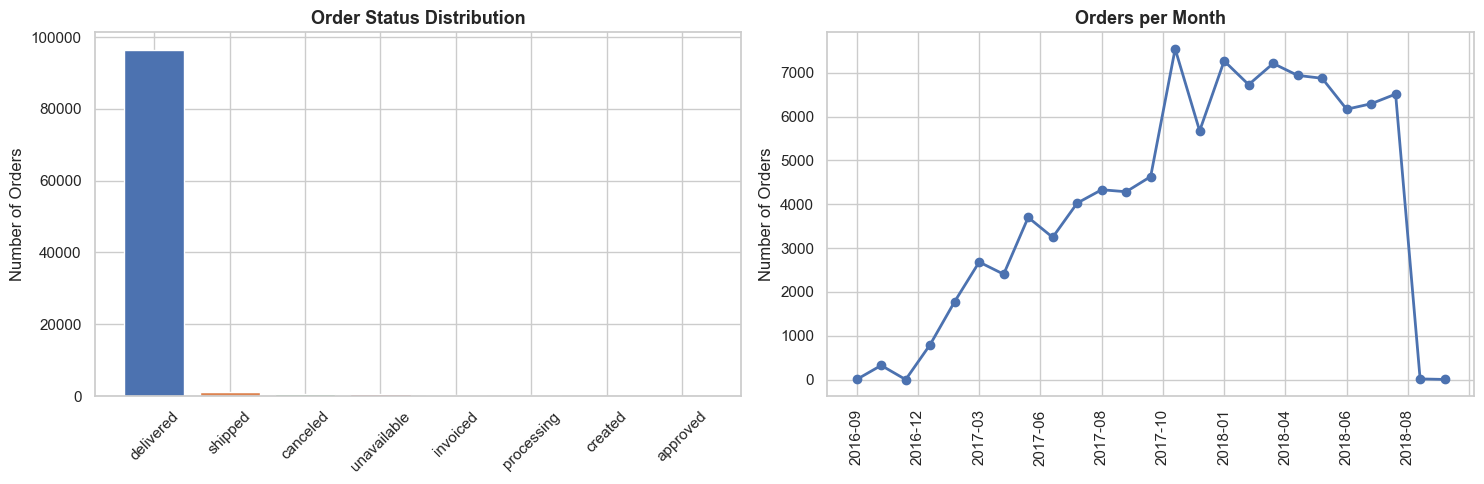

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order_status_counts = orders_full['order_status'].value_counts()
axes[0].bar(order_status_counts.index, order_status_counts.values, color=sns.color_palette("deep"))
axes[0].set_title("Order Status Distribution")
axes[0].set_ylabel("Number of Orders")
axes[0].tick_params(axis='x', rotation=45)

monthly_orders = orders_full.groupby('purchase_year_month')['order_id'].nunique().sort_index()
axes[1].plot(monthly_orders.index, monthly_orders.values, marker='o', linewidth=2)
axes[1].set_title("Orders per Month")
axes[1].set_ylabel("Number of Orders")
axes[1].tick_params(axis='x', rotation=90)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))

plt.tight_layout()
plt.show()


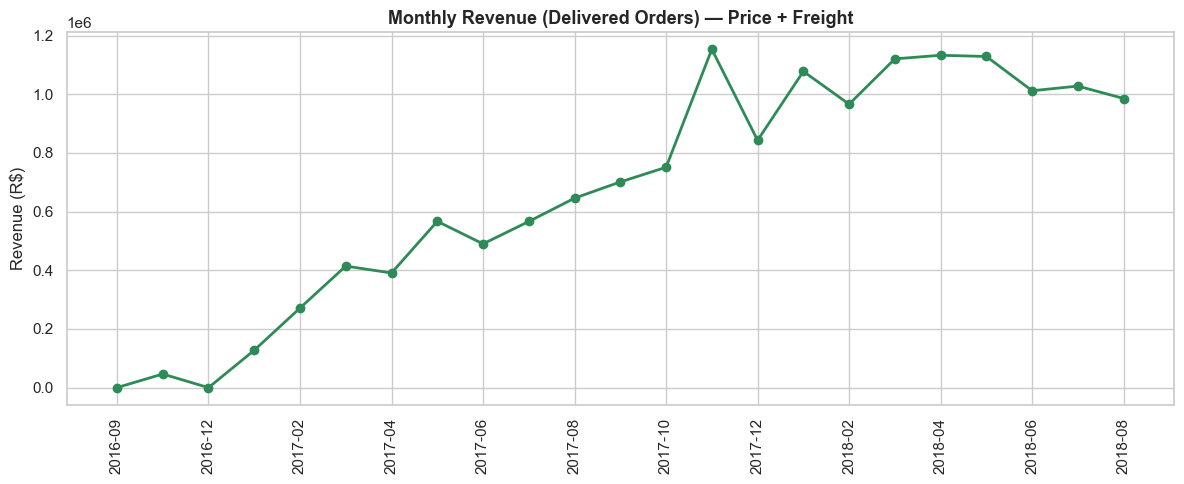

Total revenue (delivered): R$ 15,419,773.75
Total items sold (delivered): 110,197
Average order value: R$ 159.83


In [17]:
# Revenue trend (delivered orders only, using item price + freight)
delivered = master[master['order_status'] == 'delivered'].copy()

monthly_revenue = delivered.groupby('purchase_year_month')['item_total'].sum().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='seagreen', linewidth=2)
plt.title("Monthly Revenue (Delivered Orders) — Price + Freight")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=90)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(nbins=15))
plt.tight_layout()
plt.show()

print(f"Total revenue (delivered): R$ {delivered['item_total'].sum():,.2f}")
print(f"Total items sold (delivered): {len(delivered):,}")
print(f"Average order value: R$ {delivered.groupby('order_id')['item_total'].sum().mean():,.2f}")


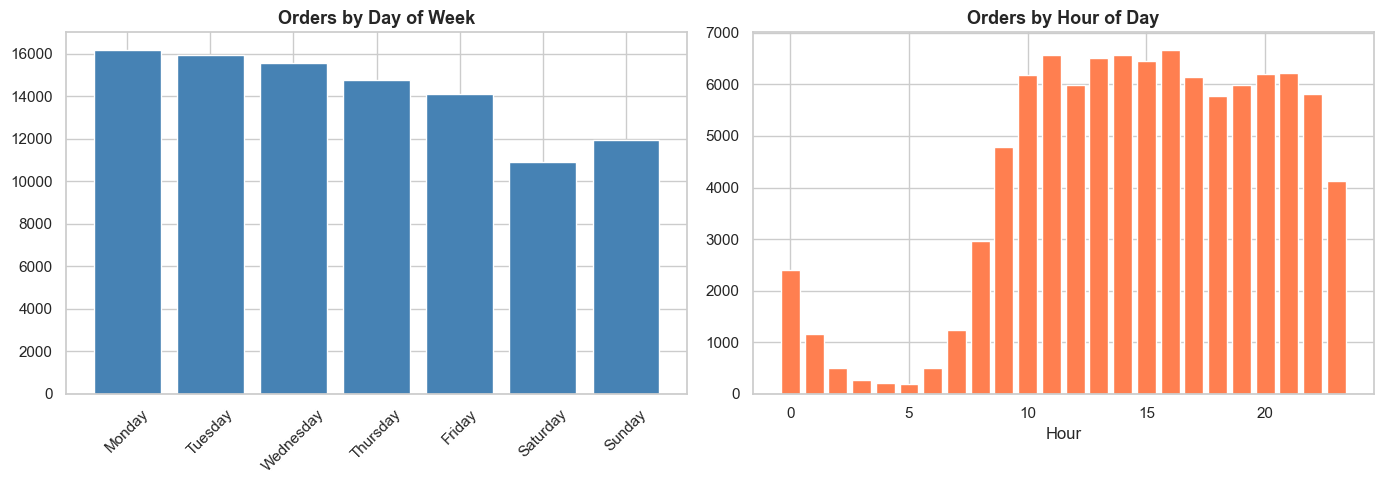

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = orders_full['purchase_dow'].value_counts().reindex(dow_order)
axes[0].bar(dow_counts.index, dow_counts.values, color='steelblue')
axes[0].set_title("Orders by Day of Week")
axes[0].tick_params(axis='x', rotation=45)

hour_counts = orders_full['purchase_hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='coral')
axes[1].set_title("Orders by Hour of Day")
axes[1].set_xlabel("Hour")

plt.tight_layout()
plt.show()


## 5. Customers & Geography

In [19]:
print("Unique customers (customer_id):", customers['customer_id'].nunique())
print("Unique customers (customer_unique_id, i.e. real people):", customers['customer_unique_id'].nunique())
print("→ repeat customers exist:", customers['customer_id'].nunique() - customers['customer_unique_id'].nunique(), "extra IDs")

repeat_counts = customers.groupby('customer_unique_id')['customer_id'].nunique()
print("Customers with more than 1 order-account:", (repeat_counts > 1).sum())


Unique customers (customer_id): 99441
Unique customers (customer_unique_id, i.e. real people): 96096
→ repeat customers exist: 3345 extra IDs
Customers with more than 1 order-account: 2997


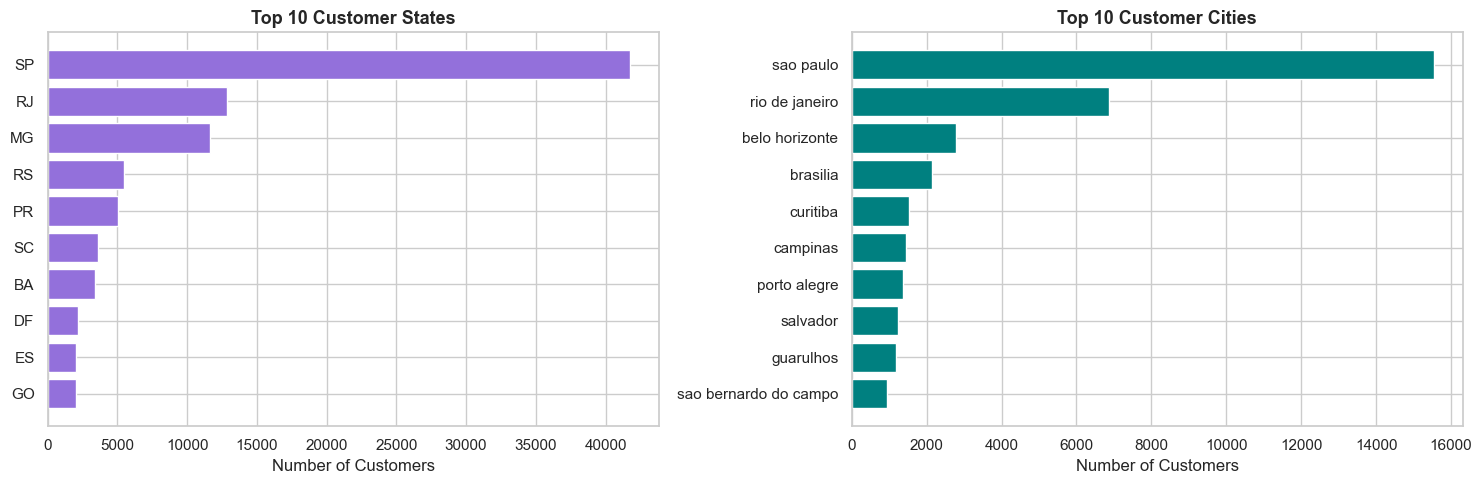

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_states = customers['customer_state'].value_counts().head(10)
axes[0].barh(top_states.index[::-1], top_states.values[::-1], color='mediumpurple')
axes[0].set_title("Top 10 Customer States")
axes[0].set_xlabel("Number of Customers")

top_cities = customers['customer_city'].value_counts().head(10)
axes[1].barh(top_cities.index[::-1], top_cities.values[::-1], color='teal')
axes[1].set_title("Top 10 Customer Cities")
axes[1].set_xlabel("Number of Customers")

plt.tight_layout()
plt.show()


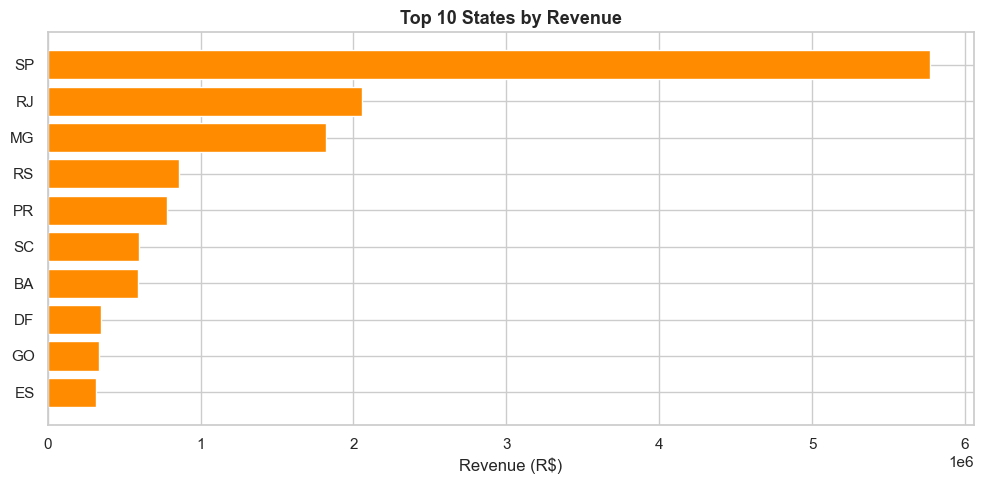

In [21]:
# Revenue by state
state_revenue = (delivered.merge(customers[['customer_id', 'customer_state']].drop_duplicates(),
                                  on='customer_id', how='left', suffixes=('', '_dup'))
                  if 'customer_state' not in delivered.columns else delivered)
state_col = 'customer_state' if 'customer_state' in delivered.columns else 'customer_state'
rev_by_state = delivered.groupby('customer_state')['item_total'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(rev_by_state.index[::-1], rev_by_state.values[::-1], color='darkorange')
plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue (R$)")
plt.tight_layout()
plt.show()


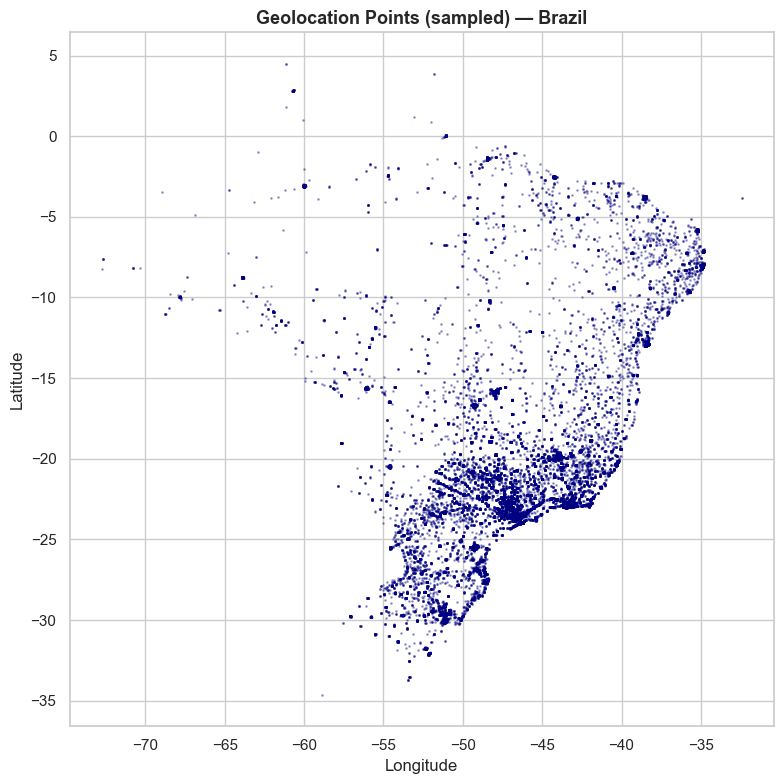

In [22]:
# Geolocation scatter (sampled) — customer density map using lat/lng, colored roughly by region
geo_sample = geoloc.sample(min(50_000, len(geoloc)), random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(geo_sample['geolocation_lng'], geo_sample['geolocation_lat'],
            s=1, alpha=0.3, color='navy')
plt.title("Geolocation Points (sampled) — Brazil")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 6. Products & Categories

Unique products: 32951
Unique categories: 74


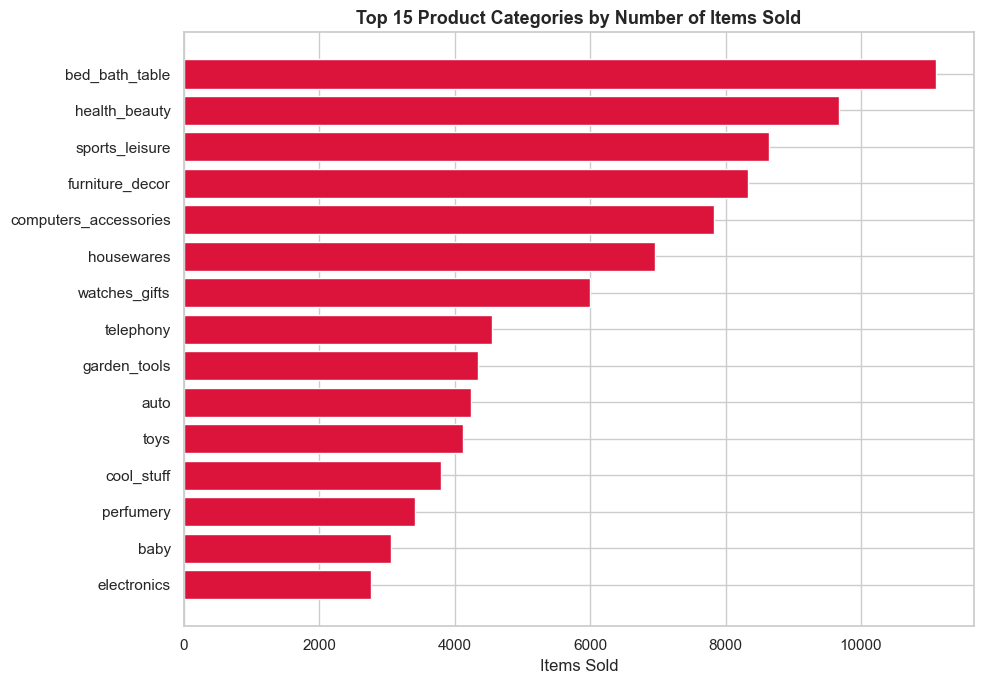

In [23]:
print("Unique products:", products['product_id'].nunique())
print("Unique categories:", products['product_category_name'].nunique())

top_cats = order_items_full['product_category_name_english'].value_counts().head(15)
plt.figure(figsize=(10, 7))
plt.barh(top_cats.index[::-1], top_cats.values[::-1], color='crimson')
plt.title("Top 15 Product Categories by Number of Items Sold")
plt.xlabel("Items Sold")
plt.tight_layout()
plt.show()


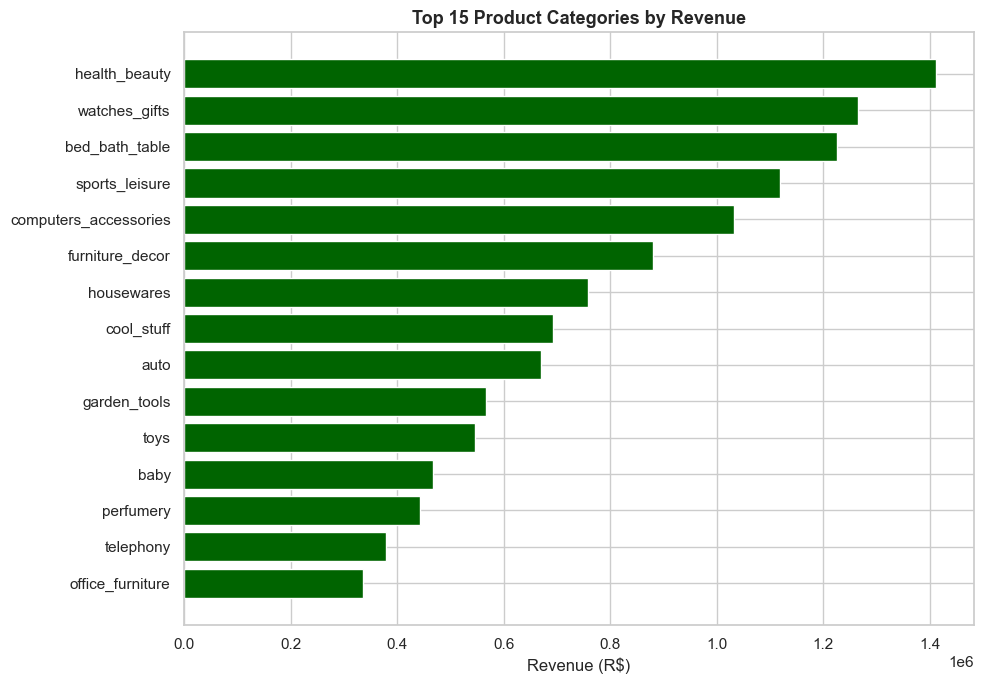

In [24]:
top_cat_revenue = (order_items_full.merge(orders_full[['order_id', 'order_status']], on='order_id', how='left')
                    .query("order_status == 'delivered'")
                    .groupby('product_category_name_english')['item_total'].sum()
                    .sort_values(ascending=False).head(15))

plt.figure(figsize=(10, 7))
plt.barh(top_cat_revenue.index[::-1], top_cat_revenue.values[::-1], color='darkgreen')
plt.title("Top 15 Product Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.tight_layout()
plt.show()


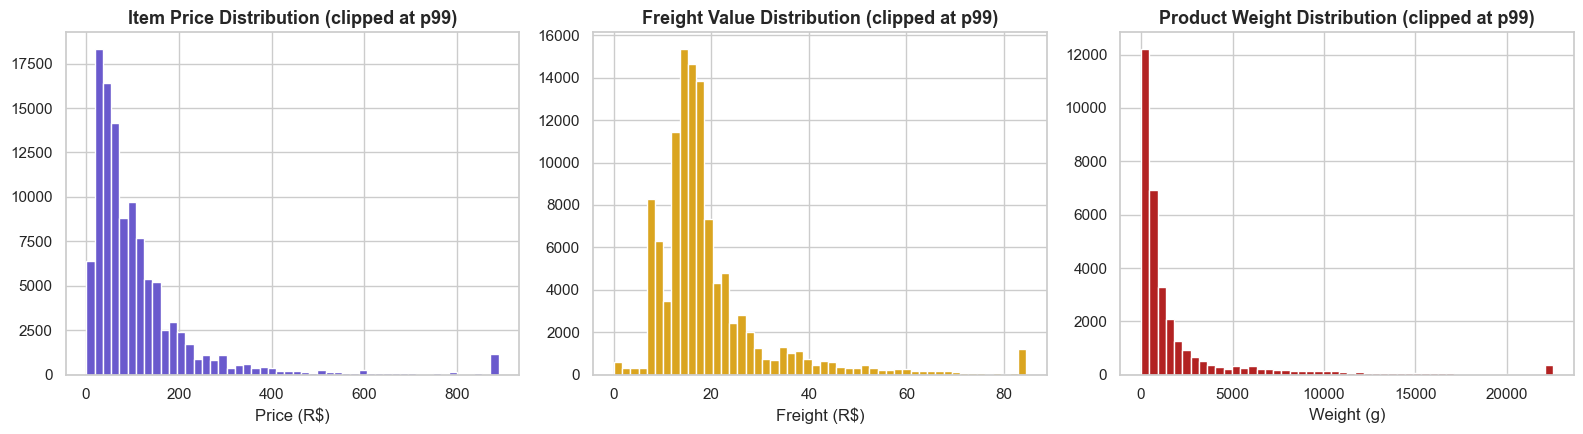

               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(order_items_full['price'].clip(upper=order_items_full['price'].quantile(0.99)),
             bins=50, color='slateblue')
axes[0].set_title("Item Price Distribution (clipped at p99)")
axes[0].set_xlabel("Price (R$)")

axes[1].hist(order_items_full['freight_value'].clip(upper=order_items_full['freight_value'].quantile(0.99)),
             bins=50, color='goldenrod')
axes[1].set_title("Freight Value Distribution (clipped at p99)")
axes[1].set_xlabel("Freight (R$)")

axes[2].hist(products['product_weight_g'].dropna().clip(upper=products['product_weight_g'].quantile(0.99)),
             bins=50, color='firebrick')
axes[2].set_title("Product Weight Distribution (clipped at p99)")
axes[2].set_xlabel("Weight (g)")

plt.tight_layout()
plt.show()

print(order_items_full[['price', 'freight_value']].describe())


## 7. Payments

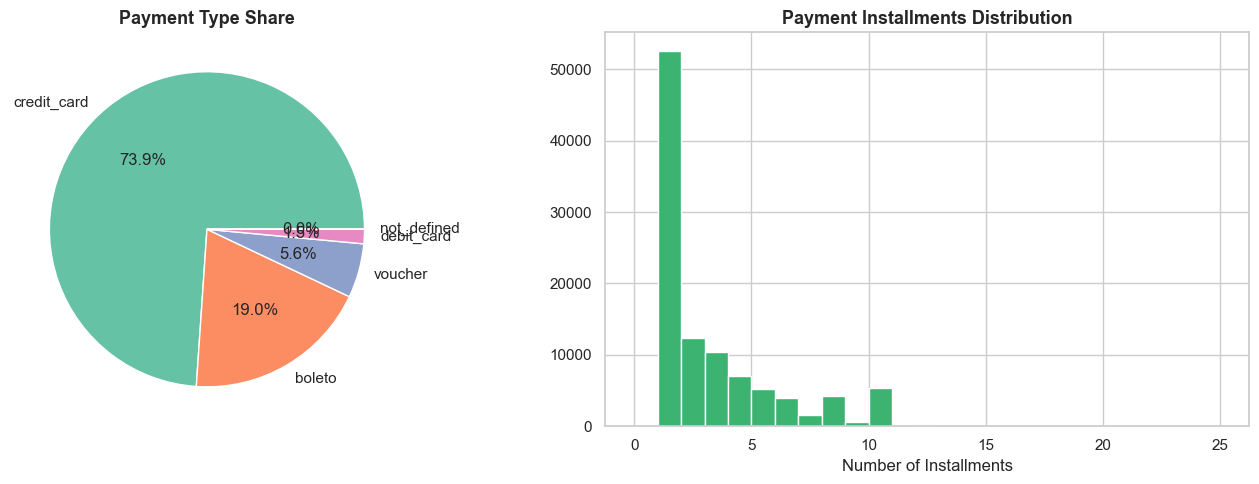

Average payment value by type:
payment_type
credit_card    163.32
boleto         145.03
debit_card     142.57
voucher         65.70
not_defined      0.00
Name: payment_value, dtype: float64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pay_type_counts = payments['payment_type'].value_counts()
axes[0].pie(pay_type_counts.values, labels=pay_type_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette("Set2"))
axes[0].set_title("Payment Type Share")

installments = payments[payments['payment_type'] != 'not_defined']['payment_installments']
axes[1].hist(installments, bins=range(0, 26), color='mediumseagreen', edgecolor='white')
axes[1].set_title("Payment Installments Distribution")
axes[1].set_xlabel("Number of Installments")

plt.tight_layout()
plt.show()

print("Average payment value by type:")
print(payments.groupby('payment_type')['payment_value'].mean().round(2).sort_values(ascending=False))


## 8. Delivery Performance

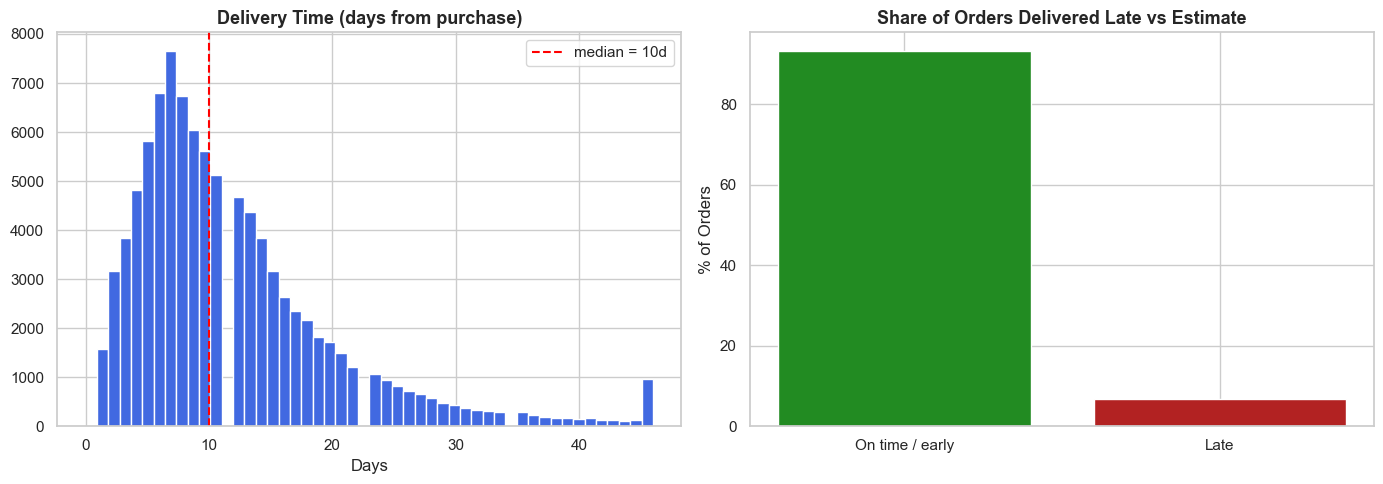

Median delivery time: 10 days
% delivered late: 6.8%


In [27]:
delivered_orders = orders_full[orders_full['order_status'] == 'delivered'].dropna(subset=['delivery_days'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(delivered_orders['delivery_days'].clip(upper=delivered_orders['delivery_days'].quantile(0.99)),
             bins=50, color='royalblue')
axes[0].axvline(delivered_orders['delivery_days'].median(), color='red', linestyle='--',
                label=f"median = {delivered_orders['delivery_days'].median():.0f}d")
axes[0].set_title("Delivery Time (days from purchase)")
axes[0].set_xlabel("Days")
axes[0].legend()

late_share = delivered_orders['is_late'].value_counts(normalize=True) * 100
axes[1].bar(['On time / early', 'Late'], 
            [late_share.get(False, 0), late_share.get(True, 0)],
            color=['forestgreen', 'firebrick'])
axes[1].set_title("Share of Orders Delivered Late vs Estimate")
axes[1].set_ylabel("% of Orders")

plt.tight_layout()
plt.show()

print(f"Median delivery time: {delivered_orders['delivery_days'].median():.0f} days")
print(f"% delivered late: {late_share.get(True, 0):.1f}%")


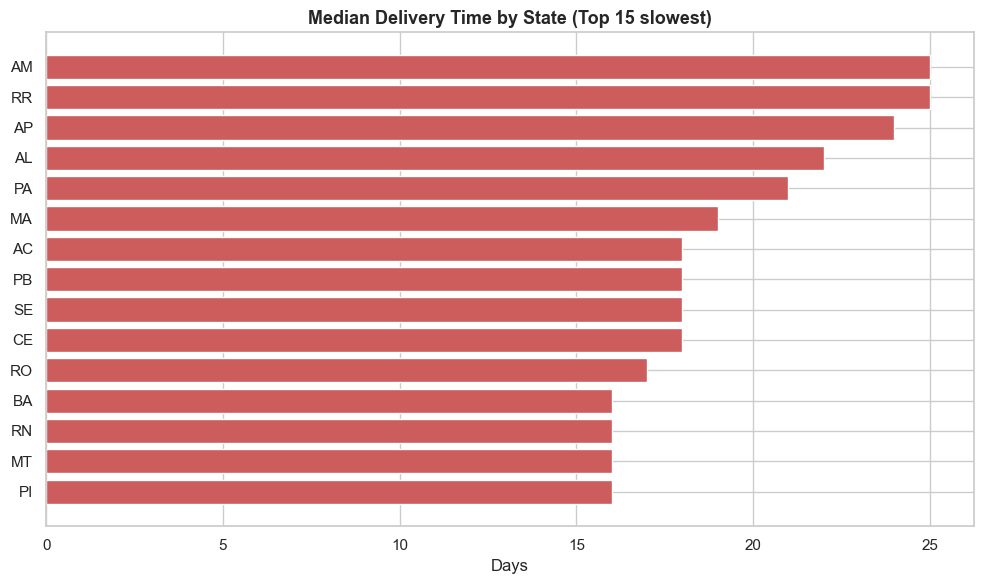

In [28]:
# Delivery time by state
delivery_by_state = delivered_orders.groupby('customer_state')['delivery_days'].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(delivery_by_state.index[::-1], delivery_by_state.values[::-1], color='indianred')
plt.title("Median Delivery Time by State (Top 15 slowest)")
plt.xlabel("Days")
plt.tight_layout()
plt.show()


## 9. Reviews / Customer Satisfaction

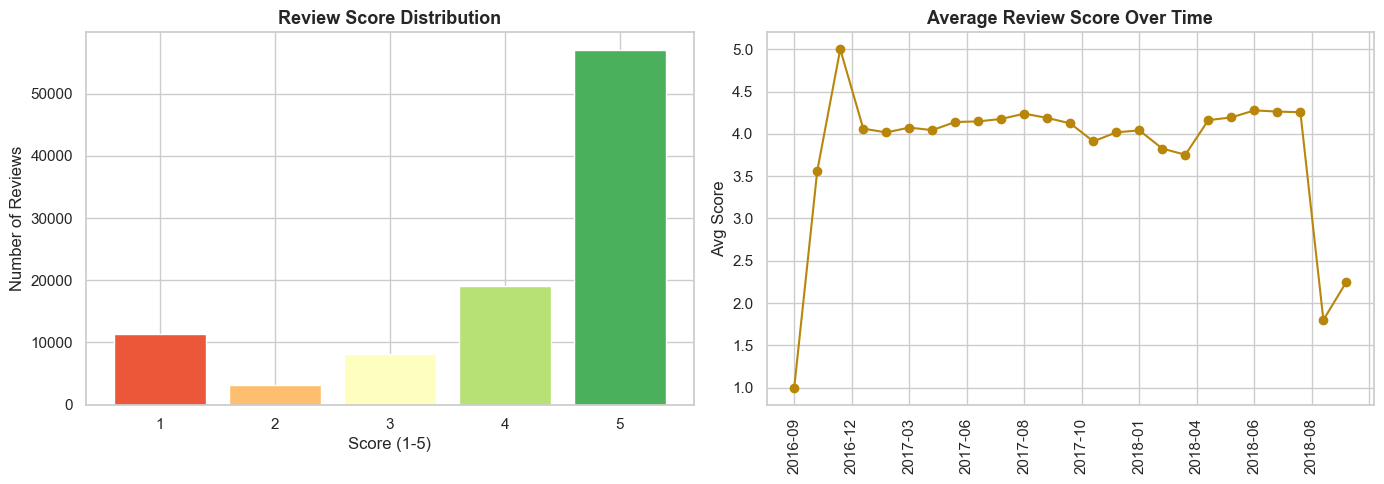

Overall average review score: 4.09
% reviews with a written comment: 41.3%


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_counts = reviews_dedup['review_score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color=sns.color_palette("RdYlGn", 5))
axes[0].set_title("Review Score Distribution")
axes[0].set_xlabel("Score (1-5)")
axes[0].set_ylabel("Number of Reviews")

avg_score_month = orders_full.dropna(subset=['review_score']).groupby('purchase_year_month')['review_score'].mean().sort_index()
axes[1].plot(avg_score_month.index, avg_score_month.values, marker='o', color='darkgoldenrod')
axes[1].set_title("Average Review Score Over Time")
axes[1].set_ylabel("Avg Score")
axes[1].tick_params(axis='x', rotation=90)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))

plt.tight_layout()
plt.show()

print(f"Overall average review score: {reviews_dedup['review_score'].mean():.2f}")
print(f"% reviews with a written comment: "
      f"{reviews_dedup['review_comment_message'].notna().mean()*100:.1f}%")


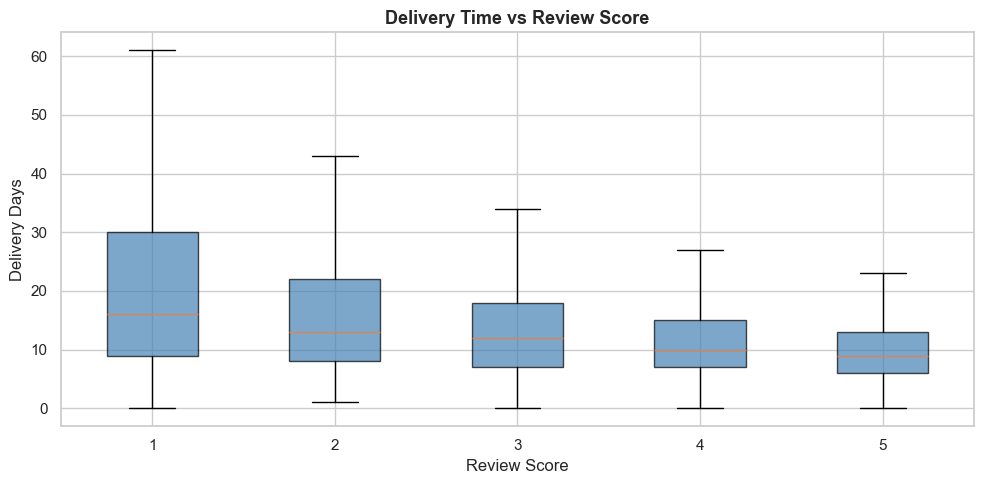

Average delivery days by review score:
review_score
1.0    20.9
2.0    16.2
3.0    13.8
4.0    11.8
5.0    10.2
Name: delivery_days, dtype: float64

Late-delivery rate by review score:
review_score
1.0    36.7
2.0    18.9
3.0     8.8
4.0     3.4
5.0     1.9
Name: is_late, dtype: float64


In [30]:
# Does delivery speed / lateness affect review score?
review_delivery = orders_full.dropna(subset=['review_score', 'delivery_days'])

plt.figure(figsize=(10, 5))
box_data = [review_delivery.loc[review_delivery['review_score'] == s, 'delivery_days'].dropna()
            for s in [1, 2, 3, 4, 5]]
plt.boxplot(box_data, labels=[1, 2, 3, 4, 5], showfliers=False, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.7))
plt.title("Delivery Time vs Review Score")
plt.ylabel("Delivery Days")
plt.xlabel("Review Score")
plt.tight_layout()
plt.show()

print("Average delivery days by review score:")
print(review_delivery.groupby('review_score')['delivery_days'].mean().round(1))

print("\nLate-delivery rate by review score:")
print((review_delivery.groupby('review_score')['is_late'].mean() * 100).round(1))


## 10. Correlations & Key Takeaways

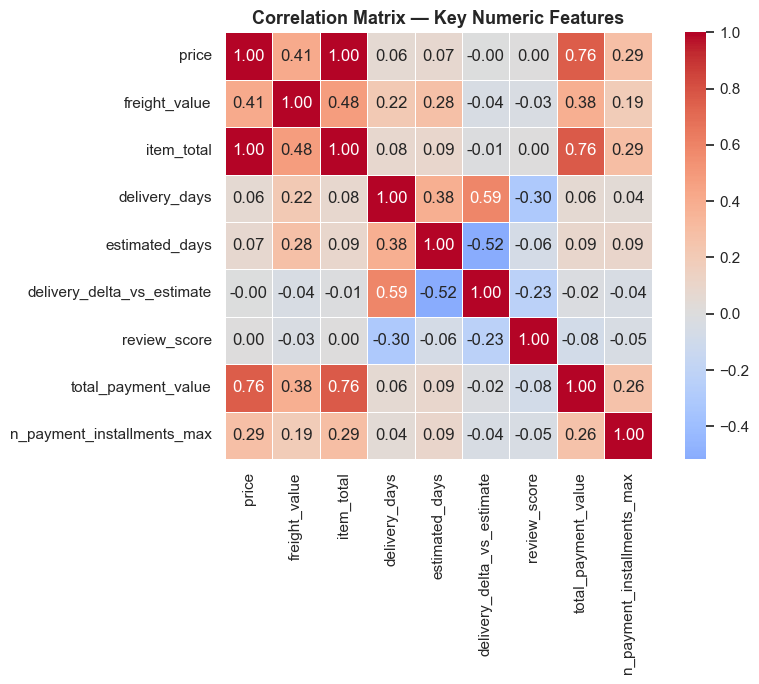

In [31]:
numeric_cols = ['price', 'freight_value', 'item_total', 'delivery_days',
                'estimated_days', 'delivery_delta_vs_estimate', 'review_score',
                'total_payment_value', 'n_payment_installments_max']
corr_df = master[numeric_cols].dropna()
corr = corr_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5)
plt.title("Correlation Matrix — Key Numeric Features")
plt.tight_layout()
plt.show()


In [32]:
print("MASTER TABLE SUMMARY")
print("="*60)
print(f"Rows (order items):        {len(master):,}")
print(f"Unique orders:              {master['order_id'].nunique():,}")
print(f"Unique customers:           {master['customer_unique_id'].nunique():,}")
print(f"Unique products:            {master['product_id'].nunique():,}")
print(f"Unique sellers:             {master['seller_id'].nunique():,}")
print(f"Date range:                 {master['order_purchase_timestamp'].min().date()} to "
      f"{master['order_purchase_timestamp'].max().date()}")
print(f"Total revenue (delivered):  R$ {delivered['item_total'].sum():,.2f}")
print(f"Overall avg review score:   {reviews_dedup['review_score'].mean():.2f} / 5")
print(f"Median delivery time:       {delivered_orders['delivery_days'].median():.0f} days")
print(f"Late delivery rate:         {late_share.get(True, 0):.1f}%")


MASTER TABLE SUMMARY
Rows (order items):        112,650
Unique orders:              98,666
Unique customers:           95,420
Unique products:            32,951
Unique sellers:             3,095
Date range:                 2016-09-04 to 2018-09-03
Total revenue (delivered):  R$ 15,419,773.75
Overall avg review score:   4.09 / 5
Median delivery time:       10 days
Late delivery rate:         6.8%


### Key takeaways

- The **master connected dataset** joins all 9 tables into a single item-level table
  (`master_connected_dataset.csv`) that can be reused for further modeling
  (e.g. churn, delivery-delay prediction, review-score prediction).
- **Order status**: the vast majority of orders are `delivered`; a small share
  are cancelled/unavailable — worth investigating separately for operational issues.
- **Seasonality**: order volume and revenue show clear month-over-month
  growth with visible peaks (e.g. Black Friday season) before flattening.
- **Geography**: order and revenue volume are heavily concentrated in a handful
  of states (SP being dominant), consistent with Brazil's population/economic
  distribution.
- **Categories**: a small number of categories drive a disproportionate share
  of both items sold and revenue — a classic long-tail distribution.
- **Payments**: credit card dominates as a payment method, with installment
  plans being common for higher-value purchases.
- **Delivery & satisfaction**: delivery time and lateness vs. the estimated
  date are visibly correlated with lower review scores — late deliveries
  associate with worse customer satisfaction, a clear lever for improvement.

Next steps could include: cohort/retention analysis on `customer_unique_id`,
seller-level performance scoring, geo-distance between customer and seller
vs. delivery time, and predictive modeling of review score or delivery delay.
